# ★ Capstone 1 — Spam Text Classifier

## TF-IDF + Classical Machine Learning

### Objective

Build a binary text classifier that predicts whether a message is Spam or Ham.

### Machine Learning Pipeline

Raw Text
↓
Text Preprocessing
↓
Train / Test Split
↓
TF-IDF
↓
Logistic Regression
↓
Prediction
↓
Evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [ ]:
import pandas as pd

df = pd.read_csv(
    "../data/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "text"]
)

df.head()

In [5]:
print(df.shape)

(5572, 2)


In [6]:
print(df["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


## 1. Dataset Exploration

Before training the model, we inspect the dataset to understand:

- Number of samples
- Columns
- Missing values
- Duplicate messages
- Class distribution

In [7]:
print("Dataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["label"].value_counts())

Dataset shape:
(5572, 2)

Columns:
['label', 'text']

Missing values:
label    0
text     0
dtype: int64

Class distribution:
label
ham     4825
spam     747
Name: count, dtype: int64


In [8]:
print("Duplicate rows:")
print(df.duplicated().sum())

Duplicate rows:
403


In [9]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:")
print(df.shape)

Shape after removing duplicates:
(5169, 2)


In [10]:
df.head(10)

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


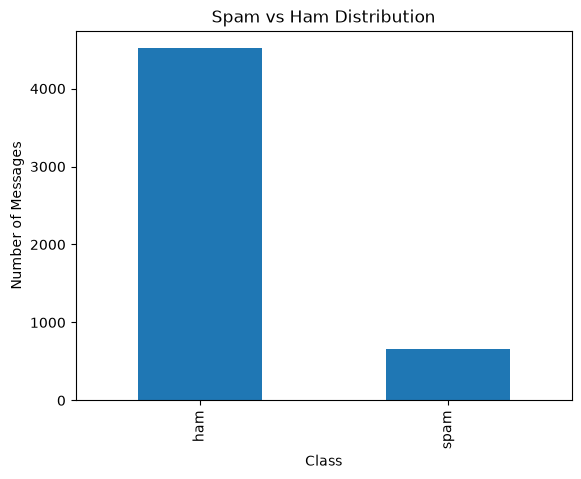

In [11]:
import matplotlib.pyplot as plt

df["label"].value_counts().plot(kind="bar")

plt.title("Spam vs Ham Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Messages")

plt.show()

In [12]:
df["target"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

df.head()

,label,text,target
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [13]:
print(df["target"].value_counts())

target
0    4516
1     653
Name: count, dtype: int64


In [14]:
X = df["text"]
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5169,)
y shape: (5169,)


## 2. Train / Test Split

The dataset is divided into training and testing data.

- Training data is used to learn patterns.
- Testing data is used to evaluate the model on unseen messages.

TF-IDF will be fitted only on the training data to avoid data leakage.

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4135
Testing samples: 1034


In [16]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
target
0    3613
1     522
Name: count, dtype: int64

Testing class distribution:
target
0    903
1    131
Name: count, dtype: int64


## 13. TF-IDF Vectorization

TF-IDF converts text into numerical features that a machine learning model can understand.

The vectorizer is fitted only on the training data.

The test data is transformed using the vocabulary learned from the training data.

This prevents information leakage.

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

In [18]:
X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:")
print(X_train_tfidf.shape)

print("\nTesting TF-IDF shape:")
print(X_test_tfidf.shape)

Training TF-IDF shape:
(4135, 7414)

Testing TF-IDF shape:
(1034, 7414)


## 14. Inspect TF-IDF Vocabulary

Inspect the words learned by the TF-IDF vectorizer.

In [19]:
feature_names = tfidf.get_feature_names_out()

print("Number of features:", len(feature_names))

print("\nFirst 30 features:")
print(feature_names[:30])

Number of features: 7414

First 30 features:
['00' '000' '000pes' '008704050406' '0089' '0121' '01223585236'
 '01223585334' '0125698789' '02' '0207' '02072069400' '03' '04' '0430'
 '05' '050703' '0578' '06' '07' '07090201529' '07090298926' '0721072'
 '07732584351' '07734396839' '07742676969' '07753741225' '0776xxxxxxx'
 '07781482378' '077xxx']


## 15. Train Logistic Regression

Logistic Regression is used as the classical Machine Learning classifier.

The model learns patterns from the TF-IDF numerical representation of the training messages.

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

model.fit(
    X_train_tfidf,
    y_train
)

print("Model training completed.")

Model training completed.


## 16. Make Predictions

Use the trained model to predict the classes of the unseen test messages.

In [21]:
y_pred = model.predict(
    X_test_tfidf
)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


## 17. Model Evaluation

Evaluate the classifier using:

- Accuracy
- Precision
- Recall
- F1 Score

In [22]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9564796905222437
Precision: 0.9777777777777777
Recall   : 0.6717557251908397
F1 Score : 0.7963800904977375


## 18. Classification Report

The classification report provides Precision, Recall, F1 Score, and support for both Ham and Spam classes.

In [23]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Ham", "Spam"]
    )
)

              precision    recall  f1-score   support

         Ham       0.95      1.00      0.98       903
        Spam       0.98      0.67      0.80       131

    accuracy                           0.96      1034
   macro avg       0.97      0.83      0.89      1034
weighted avg       0.96      0.96      0.95      1034



## 19. Confusion Matrix

The confusion matrix shows the number of:

- True Negatives
- False Positives
- False Negatives
- True Positives

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[901   2]
 [ 43  88]]


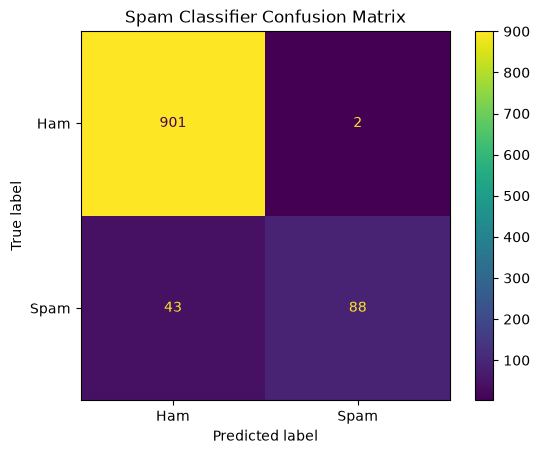

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Ham", "Spam"]
)

cm_display.plot()

plt.title("Spam Classifier Confusion Matrix")

plt.show()

## 20. Test Custom Messages

Test the trained classifier with new messages that were not part of the original dataset.

In [26]:
new_messages = [
    "Congratulations! You have won a free prize. Claim now!",
    "Can you call me when you reach home?",
    "URGENT! You have won a cash reward. Click now!",
    "Let's meet for lunch tomorrow."
]

new_messages_tfidf = tfidf.transform(
    new_messages
)

predictions = model.predict(
    new_messages_tfidf
)

for message, prediction in zip(
    new_messages,
    predictions
):
    label = "Spam" if prediction == 1 else "Ham"

    print(f"{label}: {message}")

Spam: Congratulations! You have won a free prize. Claim now!
Ham: Can you call me when you reach home?
Spam: URGENT! You have won a cash reward. Click now!
Ham: Let's meet for lunch tomorrow.


## 21. Reusable Prediction Function

Create a reusable function that accepts a new message and returns its predicted class.

In [27]:
def predict_message(message):
    message_tfidf = tfidf.transform(
        [message]
    )

    prediction = model.predict(
        message_tfidf
    )[0]

    if prediction == 1:
        return "Spam"

    return "Ham"

In [28]:
print(
    predict_message(
        "Congratulations! You won a free phone!"
    )
)

print(
    predict_message(
        "Are you free for dinner tonight?"
    )
)

Spam
Ham


## 22. Inspect Top TF-IDF Terms

Inspect the terms with the highest TF-IDF values for a few test documents.

In [29]:
def show_top_tfidf_terms(text, top_n=10):
    vector = tfidf.transform([text])

    scores = vector.toarray()[0]

    top_indices = scores.argsort()[-top_n:][::-1]

    terms = feature_names[top_indices]
    values = scores[top_indices]

    print("Message:")
    print(text)

    print("\nTop TF-IDF terms:")

    for term, value in zip(terms, values):
        print(f"{term}: {value:.4f}")

In [30]:
for message in X_test.head(3):
    show_top_tfidf_terms(message)
    print("\n" + "-" * 50 + "\n")

Message:
Good morning, my Love ... I go to sleep now and wish you a great day full of feeling better and opportunity ... You are my last thought babe, I LOVE YOU *kiss*

Top TF-IDF terms:
love: 0.4075
opportunity: 0.3640
feeling: 0.3100
kiss: 0.2859
better: 0.2702
wish: 0.2673
thought: 0.2596
sleep: 0.2596
morning: 0.2473
babe: 0.2369

--------------------------------------------------

Message:
And how you will do that, princess? :)

Top TF-IDF terms:
princess: 1.0000
〨ud: 0.0000
ú1: 0.0000
èn: 0.0000
zyada: 0.0000
zouk: 0.0000
zoom: 0.0000
zogtorius: 0.0000
zoe: 0.0000
zindgi: 0.0000

--------------------------------------------------

Message:
Cool, I'll text you when I'm on the way

Top TF-IDF terms:
cool: 0.5966
way: 0.5141
text: 0.4508
ll: 0.4202
ú1: 0.0000
èn: 0.0000
zyada: 0.0000
zouk: 0.0000
zoom: 0.0000
zogtorius: 0.0000

--------------------------------------------------



## 23. Model Summary

The complete machine learning pipeline is:

Raw Text
↓
Dataset Cleaning
↓
Train / Test Split
↓
TF-IDF Vectorization
↓
Logistic Regression
↓
Predictions
↓
Accuracy / Precision / Recall / F1
↓
Confusion Matrix
↓
Custom Message Testing
↓
Top TF-IDF Terms

## 24. Final Results

### Accuracy

The Accuracy measures the overall percentage of correctly classified messages.

### Precision

Precision measures how many messages predicted as Spam were actually Spam.

### Recall

Recall measures how many actual Spam messages were correctly detected.

### F1 Score

F1 Score combines Precision and Recall into a single metric.

### Confusion Matrix

The confusion matrix shows the correct and incorrect predictions for Ham and Spam.

### Conclusion

A Logistic Regression classifier was trained using TF-IDF features to classify SMS messages as Spam or Ham.

The model was evaluated using Accuracy, Precision, Recall, F1 Score, Classification Report, and Confusion Matrix.

The model was also tested with new messages and the highest TF-IDF terms were inspected for selected documents.